# Entrenamiento del Clasificador Morfológico de Galaxias (EfficientNetB0)

Este notebook entrena un clasificador de morfología galáctica usando
**EfficientNetB0** con aprendizaje por transferencia (transfer learning) sobre
el dataset Galaxy Zoo 2 (4 clases balanceadas, 5,060 imágenes de 224x224).

**Estrategia de entrenamiento en 2 fases:**

- **Fase 1** — Backbone congelado: solo se entrena la cabeza clasificadora (15 épocas, lr=1e-3)
- **Fase 2** — Fine-tuning: se descongela el backbone y se refina con learning rate bajo (25 épocas, lr=1e-5)

**Hardware utilizado:** GPU Tesla T4 (Google Colab)
**Librería principal:** TensorFlow 2.19 con mixed precision (float16/float32)

In [5]:
# Importar librerías de ciencia de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import os

from sklearn.model_selection import train_test_split

# Configurar pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

In [6]:
import tensorflow as tf
from tensorflow import keras

# Mixed precision: float16 en capas de cómputo, float32 en acumuladores
# Reduce memoria a la mitad y acelera ~2x en GPUs con Tensor Cores (T4, V100, A100)
keras.mixed_precision.set_global_policy('mixed_float16')

# Verificar disponibilidad de GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs disponibles: {gpus}")

if gpus:
    details = tf.config.experimental.get_device_details(gpus[0])
    print(f"Nombre: {details.get('device_name', 'N/A')}")
    print(f"TF version: {tf.__version__}")
else:
    print("⚠ No se detectó GPU — verifica que activaste T4 en el entorno")

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Nombre: Tesla T4
TF version: 2.19.0


In [7]:
# Montar Google Drive para acceder a las imágenes y guardar checkpoints
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Definir directorio raíz del proyecto en Google Drive
# Todo (imágenes, CSV, modelos) se almacena relativo a este path
path = '/content/drive/MyDrive/DCD_Archivos/Sideral'
os.chdir(path)

In [9]:
# Hiperparámetros globales del entrenamiento
IMG_SIZE   = 224          # Resolución de entrada de EfficientNetB0 (224x224 px)
BATCH_SIZE = 64           # Tamaño de batch; reducir a 32 si se agota la VRAM
SEED       = 3            # Semilla para reproducibilidad
AUTOTUNE   = tf.data.AUTOTUNE  # Optimización automática del pipeline de datos

# Orden de clases fijo — CRÍTICO: debe coincidir en entrenamiento e inferencia
CLASSES      = ['elliptical', 'edge_on', 'merger', 'spiral']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

In [10]:
# Cargar dataset etiquetado y codificar clases como índices enteros
df = pd.read_csv('./gz2_labels_clean.csv')  # columnas: dr7objid, label, path
df['label_idx'] = df['label'].map(CLASS_TO_IDX)

print("Clases:", CLASS_TO_IDX)
print("Distribución:\n", df['label'].value_counts())

Clases: {'elliptical': 0, 'edge_on': 1, 'merger': 2, 'spiral': 3}
Distribución:
 label
edge_on       1265
merger        1265
spiral        1265
elliptical    1265
Name: count, dtype: int64
Nulls en path o label: {'path': 0, 'label_idx': 0}


In [11]:
# Adaptar rutas de imagen al entorno de Colab
# Las rutas del CSV apuntan al dataset local; las ajustamos al directorio de Drive
df['path'] = df['path'].apply(
    lambda x: path + '/images_efficientnet/' + os.path.basename(x)
)
print("Ejemplo de path:", df.path.iloc[0])

/content/drive/MyDrive/DCD_Archivos/Sideral/images_efficientnet/265203.jpg


In [12]:
# Split estratificado: train (70%) / val (15%) / test (15%)
# Estratificado garantiza que cada split mantiene la distribución de clases
# El split se hace sobre el DataFrame ANTES de construir los tf.data.Dataset

df_train, df_temp = train_test_split(
    df,
    test_size=0.3,
    random_state=SEED,
    stratify=df['label_idx']
)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=df_temp['label_idx']
)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")


Train: 3,542 | Val: 759 | Test: 759


In [13]:
# Pipeline de carga de imágenes y data augmentation

def load_image(path, label):
    """Lee y normaliza una imagen para EfficientNetB0.

    Decodifica el JPEG, redimensiona a IMG_SIZExIMG_SIZE y aplica la
    normalización de ImageNet requerida por los pesos preentrenados.
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # Normalización EfficientNet: escala a [-1, 1] (distinto de la normalización estándar)
    img = keras.applications.efficientnet.preprocess_input(img)
    return img, label

def augment(img, label):
    """Aplica aumentación aleatoria para mejorar generalización del modelo.

    Técnicas: flip horizontal/vertical y rotación (±45°).
    Solo se aplica al conjunto de entrenamiento, nunca a val/test.
    """
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.keras.layers.RandomRotation(0.125)(img)  # ±45°
    return img, label

In [14]:
# Construir pipelines tf.data optimizados para entrenamiento en GPU

def build_dataset(df_split, augment_data=False, shuffle=False):
    """Construye un tf.data.Dataset a partir de un DataFrame.

    Args:
        df_split: DataFrame con columnas 'path' y 'label_idx'
        augment_data: Si True, aplica data augmentation (solo en train)
        shuffle: Si True, mezcla los datos en cada época

    Returns:
        tf.data.Dataset batched y prefetchado para máxima eficiencia de GPU
    """
    paths  = df_split['path'].values
    labels = df_split['label_idx'].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df_split), seed=SEED)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(df_train, augment_data=True, shuffle=True)
val_ds   = build_dataset(df_val)
test_ds  = build_dataset(df_test)


Batches — Train: 56 | Val: 12 | Test: 12


In [ ]:
# Verificar visualmente un batch del dataset de entrenamiento antes de entrenar
# Nota: revertimos la normalización de EfficientNet (solo para visualización)
import matplotlib.pyplot as plt

IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

imgs, labels = next(iter(train_ds))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.flat):
    # preprocess_input de EfficientNet escala a [-1,1]; revertimos para visualizar
    img_display = (imgs[i].numpy() + 1.0) / 2.0
    img_display = np.clip(img_display, 0, 1)
    ax.imshow(img_display)
    ax.set_title(IDX_TO_CLASS[labels[i].numpy()], fontsize=10)
    ax.axis('off')

plt.suptitle('Muestra de imágenes aumentadas (train set)', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
# Construcción del modelo — EfficientNetB0 con Transfer Learning
#
# Arquitectura:
#   - Backbone: EfficientNetB0 preentrenado en ImageNet (sin capa clasificadora)
#   - Pooling: GlobalAveragePooling2D
#   - Regularización: Dropout(0.3)
#   - Salida: Dense(NUM_CLASSES, activation='softmax')
#
# Fase 1: backbone.trainable = False (solo cabeza)
# Fase 2: backbone.trainable = True  (fine-tuning completo, lr bajo)

NUM_CLASSES = 4

backbone = keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)
backbone.trainable = False  # Congelar backbone en Fase 1

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = backbone(inputs, training=False)
x       = keras.layers.GlobalAveragePooling2D()(x)
x       = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

model = keras.Model(inputs, outputs)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


Capas totales: 8 | Entrenables en Fase 1: 7


In [13]:
# Verificar que el modelo puede hacer forward pass en GPU
with tf.device('/GPU:0'):
    sample_batch = next(iter(train_ds))
    test_output = model(sample_batch[0], training=False)
    print(f"✓ Forward pass en GPU exitoso")
    print(f"  Entrada: {sample_batch[0].shape} | Salida: {test_output.shape}")

# Monitorear uso de memoria
print("\nUso de memoria GPU:")
for gpu in tf.config.list_physical_devices('GPU'):
    mem = tf.config.experimental.get_memory_info(gpu.name)
    print(f"  {gpu.name}: {mem}")

✓ Forward pass exitoso en GPU
  Input shape:  (64, 224, 224, 3)
  Output shape: (64, 4)

Memoria GPU:
{'current': 132127744, 'peak': 3469115136}


In [21]:
# Hiperparámetros de entrenamiento por fase
#
# Fase 1 — Backbone congelado, solo cabeza clasificadora
#   lr alto (1e-3): la cabeza parte de pesos aleatorios y necesita convergencia rápida
#
# Fase 2 — Fine-tuning completo con backbone descongelado
#   lr muy bajo (1e-5): evita destruir las representaciones aprendidas de ImageNet

FASE1_EPOCHS = 15
FASE1_LR     = 1e-3
FASE2_EPOCHS = 25
FASE2_LR     = 1e-5

In [14]:
# Compilar modelo para Fase 1
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FASE1_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks: guardar mejor checkpoint y detener si no mejora
callbacks_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='efficientnet_gz2_fase1_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Entrenar Fase 1
history_fase1 = model.fit(
    train_ds,
    epochs=FASE1_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_fase1
)


FASE 1 — Entrenando cabeza clasificadora
Epochs: 15 | LR: 0.001 | Batch: 64
Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6118 - loss: 1.1316 
Epoch 1: val_accuracy improved from None to 0.71542, saving model to efficientnet_gz2_fase1_best.keras

Epoch 1: finished saving model to efficientnet_gz2_fase1_best.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 1424s 25s/step - accuracy: 0.6920 - loss: 0.9095 - val_accuracy: 0.7154 - val_loss: 0.8012 - learning_rate: 0.0010
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.7748 - loss: 0.6579
Epoch 2: val_accuracy improved from 0.71542 to 0.84980, saving model to efficientnet_gz2_fase1_best.keras

Epoch 2: finished saving model to efficientnet_gz2_fase1_best.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 18s 324ms/step - accuracy: 0.7722 - loss: 0.6425 - val_accuracy: 0.8498 - val_loss: 0.6442 - learning_rate: 0.0010
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.8113 - loss: 0.5547
Epoch 3: val_accuracy improved from

In [23]:
# Función de evaluación: genera reporte de clasificación y matriz de confusión
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, dataset, split_name, phase_name):
    """Evalúa el modelo e imprime métricas completas por clase.

    Args:
        model: Modelo Keras entrenado
        dataset: tf.data.Dataset del split a evaluar
        split_name: Nombre descriptivo del split ('Validation', 'Test')
        phase_name: Nombre de la fase de entrenamiento ('Fase 1', 'Fase 2')

    Returns:
        Tupla (y_true, y_pred) con etiquetas reales y predichas
    """
    y_true, y_pred = [], []

    for imgs, labels in dataset:
        preds = model.predict(imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    print(f"\n{'='*60}")
    print(f" {phase_name} — Reporte en {split_name}")
    print('='*60)
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Matriz de Confusión — {phase_name} ({split_name})')
    plt.tight_layout()
    plt.show()

    return y_true, y_pred


Classification Report — Fase 1 (Validation)
              precision    recall  f1-score   support

  elliptical     0.8683    0.9368    0.9013       190
     edge_on     0.9293    0.9735    0.9509       189
      merger     0.8447    0.7158    0.7749       190
      spiral     0.8769    0.9000    0.8883       190

    accuracy                         0.8814       759
   macro avg     0.8798    0.8815    0.8789       759
weighted avg     0.8797    0.8814    0.8788       759



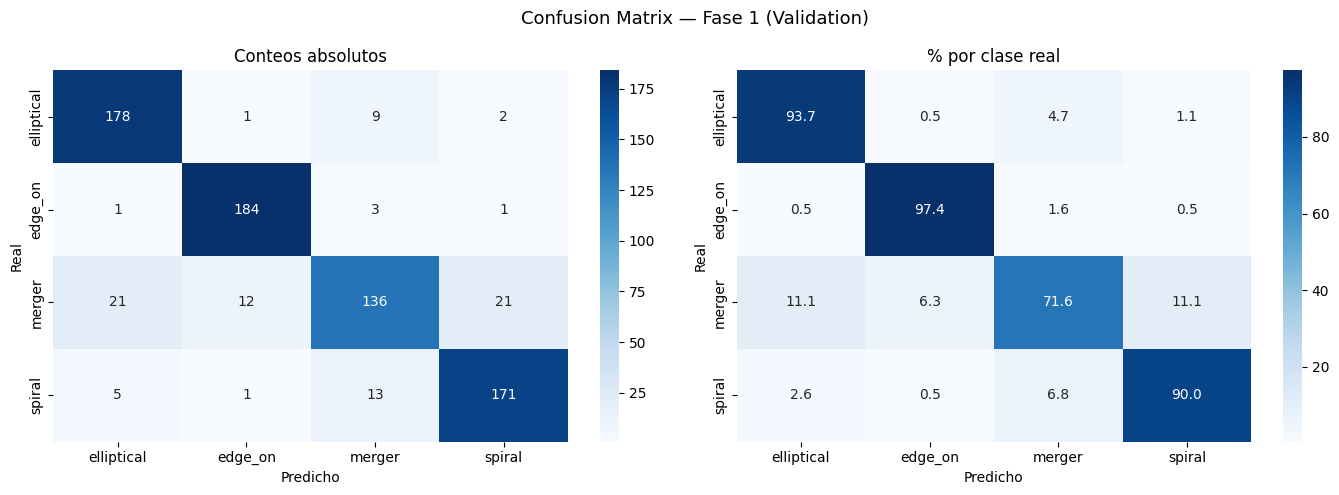

  Guardada: cm_fase_1_validation.png

── Errores por clase (───────────────────────────────────)
  elliptical    correctos:  178  errores:   12  recall: 93.7%
             → mal clasificado como 'edge_on': 1 (0.5%)
             → mal clasificado como 'merger': 9 (4.7%)
             → mal clasificado como 'spiral': 2 (1.1%)
  edge_on       correctos:  184  errores:    5  recall: 97.4%
             → mal clasificado como 'elliptical': 1 (0.5%)
             → mal clasificado como 'merger': 3 (1.6%)
             → mal clasificado como 'spiral': 1 (0.5%)
  merger        correctos:  136  errores:   54  recall: 71.6%
             → mal clasificado como 'elliptical': 21 (11.1%)
             → mal clasificado como 'edge_on': 12 (6.3%)
             → mal clasificado como 'spiral': 21 (11.1%)
  spiral        correctos:  171  errores:   19  recall: 90.0%
             → mal clasificado como 'elliptical': 5 (2.6%)
             → mal clasificado como 'edge_on': 1 (0.5%)
             → mal clasificado

In [ ]:
# Evaluar Fase 1 en conjunto de validación
y_true_f1, y_pred_f1 = evaluate_model(model, val_ds, 'Validation', 'Fase 1')

In [16]:
# Fase 2 — Fine-tuning completo del backbone
#
# Partimos del mejor checkpoint de Fase 1 para evitar que el ruido
# de los últimos epochs de la Fase 1 contamine el punto de inicio
model.load_weights('efficientnet_gz2_fase1_best.keras')

# Descongelar el backbone (todas las capas son entrenables)
# Las capas BatchNorm se mantienen en modo inferencia (training=False)
# para evitar que estadísticas de ImageNet sean sobreescritas por el dataset pequeño
backbone.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FASE2_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='efficientnet_gz2_fase2_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Entrenar Fase 2
history_fase2 = model.fit(
    train_ds,
    epochs=FASE2_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_fase2
)


✓ Pesos restaurados al mejor checkpoint de Fase 1

Backbone: 238 capas total
  Convolucionales entrenables : 23
  BatchNorm congeladas        : 49
  Congeladas total            : 215

FASE 2 — Fine-tuning (BatchNorm backbone congelado)
Epochs: 25 | LR: 1e-05 | Batch: 64
Epoch 1/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.8394 - loss: 0.4178
Epoch 1: val_accuracy improved from None to 0.89460, saving model to efficientnet_gz2_fase2_best.keras

Epoch 1: finished saving model to efficientnet_gz2_fase2_best.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.8346 - loss: 0.4263 - val_accuracy: 0.8946 - val_loss: 0.3293 - learning_rate: 1.0000e-05
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.8472 - loss: 0.4107
Epoch 2: val_accuracy did not improve from 0.89460
56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 312ms/step - accuracy: 0.8475 - loss: 0.4070 - val_accuracy: 0.8946 - val_loss: 0.3112 - learning_rate: 1.0000e-05
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 26


Classification Report — Fase 2 (Validation)
              precision    recall  f1-score   support

  elliptical     0.9343    0.9737    0.9536       190
     edge_on     0.9388    0.9735    0.9558       189
      merger     0.8876    0.7895    0.8357       190
      spiral     0.8929    0.9211    0.9067       190

    accuracy                         0.9144       759
   macro avg     0.9134    0.9144    0.9130       759
weighted avg     0.9134    0.9144    0.9129       759



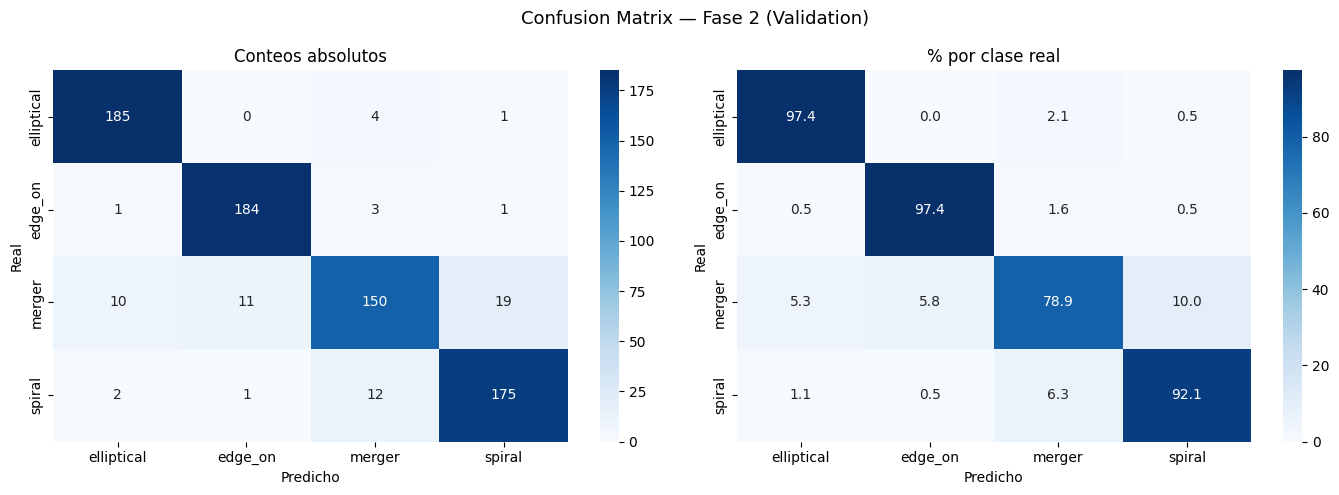

  Guardada: cm_fase_2_validation.png

── Errores por clase (───────────────────────────────────)
  elliptical    correctos:  185  errores:    5  recall: 97.4%
             → mal clasificado como 'merger': 4 (2.1%)
             → mal clasificado como 'spiral': 1 (0.5%)
  edge_on       correctos:  184  errores:    5  recall: 97.4%
             → mal clasificado como 'elliptical': 1 (0.5%)
             → mal clasificado como 'merger': 3 (1.6%)
             → mal clasificado como 'spiral': 1 (0.5%)
  merger        correctos:  150  errores:   40  recall: 78.9%
             → mal clasificado como 'elliptical': 10 (5.3%)
             → mal clasificado como 'edge_on': 11 (5.8%)
             → mal clasificado como 'spiral': 19 (10.0%)
  spiral        correctos:  175  errores:   15  recall: 92.1%
             → mal clasificado como 'elliptical': 2 (1.1%)
             → mal clasificado como 'edge_on': 1 (0.5%)
             → mal clasificado como 'merger': 12 (6.3%)


In [ ]:
# Evaluar Fase 2 en conjunto de validación
y_true_f2, y_pred_f2 = evaluate_model(model, val_ds, 'Validation', 'Fase 2')

In [ ]:
# Visualizar curvas de entrenamiento de ambas fases en una sola figura
# La línea discontinua vertical marca la transición de Fase 1 a Fase 2

def plot_history(h1, h2):
    """Grafica accuracy y loss de las dos fases de entrenamiento."""
    acc  = h1.history['accuracy']     + h2.history['accuracy']
    val  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss']         + h2.history['loss']
    vloss= h1.history['val_loss']     + h2.history['val_loss']
    n_f1 = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(acc, label='Train accuracy')
    ax1.plot(val, label='Val accuracy')
    ax1.axvline(x=n_f1 - 1, color='gray', linestyle='--', label='Inicio Fase 2')
    ax1.set_title('Accuracy — Fases 1 y 2')
    ax1.legend()

    ax2.plot(loss, label='Train loss')
    ax2.plot(vloss, label='Val loss')
    ax2.axvline(x=n_f1 - 1, color='gray', linestyle='--', label='Inicio Fase 2')
    ax2.set_title('Loss — Fases 1 y 2')
    ax2.legend()

    plt.tight_layout()
    plt.show()

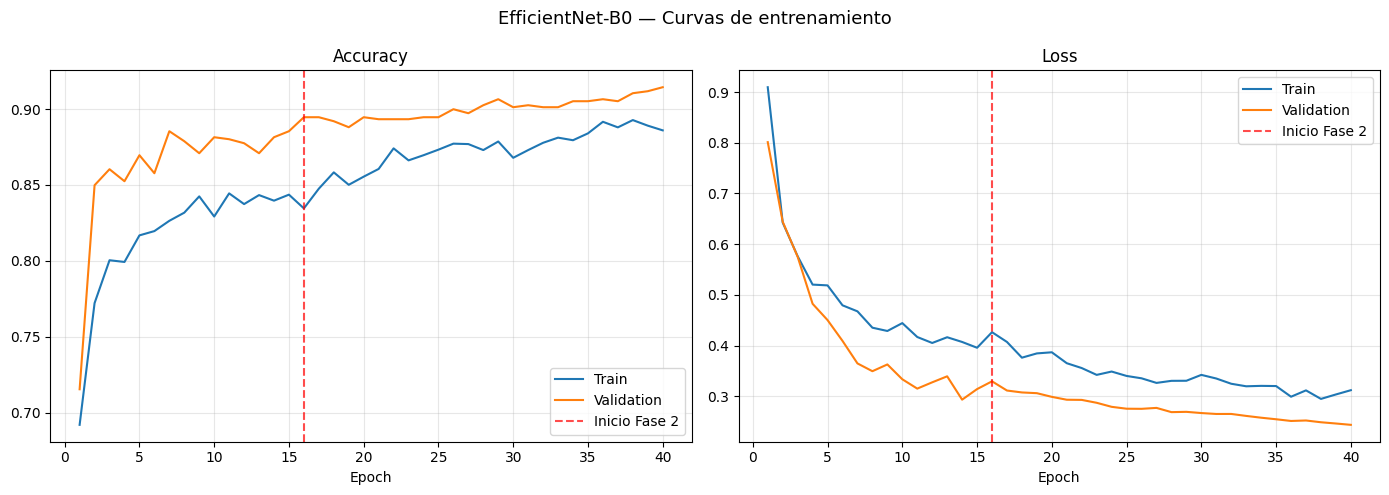

In [ ]:
# Graficar curvas de entrenamiento completas (Fase 1 + Fase 2)
plot_history(history_fase1, history_fase2)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✓ Mejor checkpoint de Fase 2 cargado

12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8999 - loss: 0.2785

── Métricas globales ────────────────────────────
  Test accuracy : 0.8999
  Test loss     : 0.2785

Classification Report — Fase 2 (Test)
              precision    recall  f1-score   support

  elliptical     0.8878    0.9158    0.9016       190
     edge_on     0.9492    0.9842    0.9664       190
      merger     0.8539    0.8000    0.8261       190
      spiral     0.9043    0.8995    0.9019       189

    accuracy                         0.8999       759
   macro avg     0.8988    0.8999    0.8990       759
weighted avg     0.8988    0.8999    0.8990       759



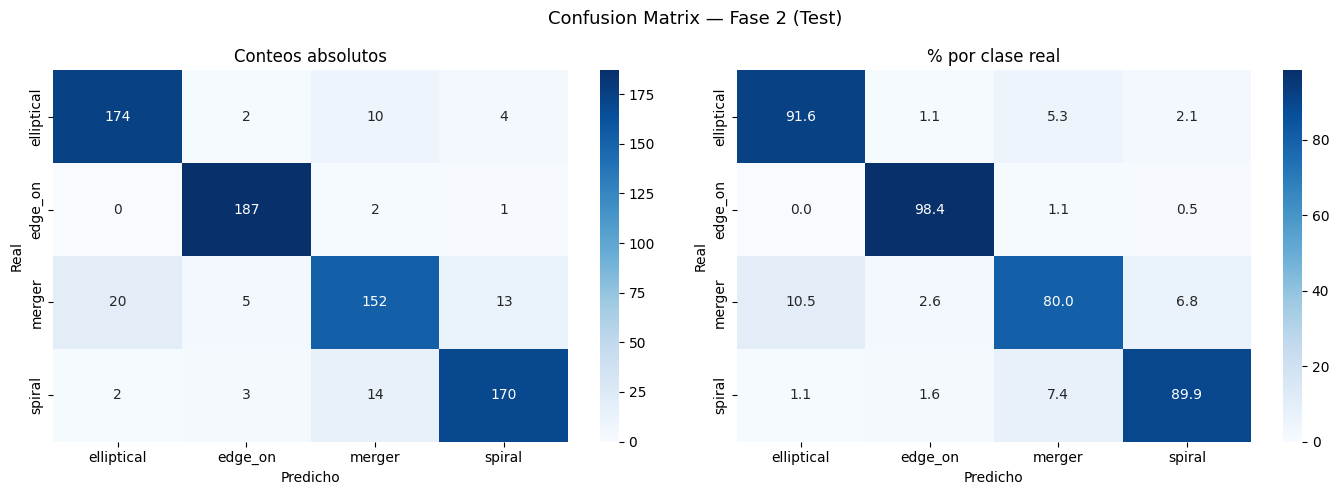

  Guardada: cm_fase_2_test.png

── Errores por clase (───────────────────────────────────)
  elliptical    correctos:  174  errores:   16  recall: 91.6%
             → mal clasificado como 'edge_on': 2 (1.1%)
             → mal clasificado como 'merger': 10 (5.3%)
             → mal clasificado como 'spiral': 4 (2.1%)
  edge_on       correctos:  187  errores:    3  recall: 98.4%
             → mal clasificado como 'merger': 2 (1.1%)
             → mal clasificado como 'spiral': 1 (0.5%)
  merger        correctos:  152  errores:   38  recall: 80.0%
             → mal clasificado como 'elliptical': 20 (10.5%)
             → mal clasificado como 'edge_on': 5 (2.6%)
             → mal clasificado como 'spiral': 13 (6.8%)
  spiral        correctos:  170  errores:   19  recall: 89.9%
             → mal clasificado como 'elliptical': 2 (1.1%)
             → mal clasificado como 'edge_on': 3 (1.6%)
             → mal clasificado como 'merger': 14 (7.4%)


NameError: name 'history_fase1' is not defined

In [26]:
# Evaluación final sobre el conjunto de TEST (no visto durante entrenamiento)
# Cargamos el mejor checkpoint de Fase 2 para garantizar resultados reproducibles

model.load_weights('/content/drive/MyDrive/DCD_Archivos/Sideral/efficientnet_gz2_fase2_best.keras')
y_true_test, y_pred_test = evaluate_model(model, test_ds, 'Test', 'Evaluación Final')

In [27]:
# Guardar modelo final y verificar integridad antes de subirlo a Hugging Face

# Tamaño del archivo en disco
size_mb = os.path.getsize('efficientnet_gz2_fase2_best.keras') / (1024 ** 2)
print(f"Tamaño del modelo: {size_mb:.1f} MB")

# Cargar y verificar que el modelo carga sin errores
model_loaded = tf.keras.models.load_model('efficientnet_gz2_fase2_best.keras')
print("✓ Modelo cargado correctamente")

# Test de inferencia con un batch real
sample_imgs, sample_labels = next(iter(test_ds))
preds = model_loaded.predict(sample_imgs[:4], verbose=0)
print("\nPredicciones de prueba (4 imágenes):")
for i, pred in enumerate(preds):
    clase_pred = CLASSES[np.argmax(pred)]
    clase_real = CLASSES[sample_labels[i].numpy()]
    confianza  = np.max(pred)
    estado     = '✓' if clase_pred == clase_real else '✗'
    print(f"  [{estado}] Real: {clase_real:12s} | Predicho: {clase_pred:12s} | Confianza: {confianza:.2%}")

Tamaño del modelo: 45.3 MB
✓ Modelo cargado correctamente
  Input shape esperado : (None, 224, 224, 3)
  Output shape         : (1, 4)
  Clases               : ['elliptical', 'edge_on', 'merger', 'spiral']
  Suma de probabilidades (debe ser ~1.0): 1.0000
